In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from datasets import load_dataset
from dataset import NLIDataset

class ESIMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super(ESIMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.encoder = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_size, bidirectional=True)
        self.inference_encoder = nn.LSTM(hidden_size * 8, hidden_size, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 8, 3)  # 3分类
        self.act = nn.Tanh()

    def forward(self, premise, premise_mask, hypothesis, hypothesis_mask):

        a_emb = self.embedding(premise)  # (batch_size, seq_len, emb_dim)
        b_emb = self.embedding(hypothesis)

        a_encoded, _ = self.encoder(a_emb)  # (batch_size, seq_len, 2*hidden_size)
        b_encoded, _ = self.encoder(b_emb)

        attn = torch.matmul(a_encoded, b_encoded.transpose(1, 2))  # (batch_size, a_len, b_len)

        a_tilde = torch.matmul(F.softmax(attn, dim=2), b_encoded)
        b_tilde = torch.matmul(F.softmax(attn, dim=1).transpose(1, 2), a_encoded)

        m_a = torch.cat([a_encoded, a_tilde, a_encoded - a_tilde, a_encoded * a_tilde], dim=2)
        m_b = torch.cat([b_encoded, b_tilde, b_encoded - b_tilde, b_encoded * b_tilde], dim=2)

        v_a, _ = self.inference_encoder(m_a)
        v_b, _ = self.inference_encoder(m_b)

        v_a = torch.cat([v_a.max(dim=1)[0], v_a.mean(dim=1)], dim=1)
        v_b = torch.cat([v_b.max(dim=1)[0], v_b.mean(dim=1)], dim=1)
        v = torch.cat([v_a, v_b], dim=1)

        logits = self.act(self.fc(v))
        return logits

In [35]:
snli_dataset = load_dataset("snli")

train_raw_dataset = snli_dataset["test"]
test_raw_dataset  =snli_dataset["validation"]

tokenizer = AutoTokenizer.from_pretrained("gpt2")
vocab_size = tokenizer.vocab_size
max_len = 64
embedding_dim = 128
hidden_size = 128
epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = NLIDataset(train_raw_dataset, tokenizer, max_len)
test_dataset = NLIDataset(test_raw_dataset, tokenizer, max_len)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

criterion = nn.CrossEntropyLoss()
model = ESIMModel(vocab_size, embedding_dim, hidden_size).to((device))
optimizer = torch.optim.AdamW(model.parameters())

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for pre, pre_mask, hypo, hypo_mask, label in train_loader:
        pre, pre_mask, hypo, hypo_mask, label = pre.to(device), pre_mask.to(device), hypo.to(device), hypo_mask.to(device), label.to(device)

        # Forward pass
        outputs = model(pre, pre_mask, hypo, hypo_mask)
        loss = criterion(outputs, label)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        train_loss += loss.item() * pre.size(0)
        train_correct += (outputs.argmax(dim=1) == label).sum().item()
        train_total += label.size(0)
        
    model.eval()
    test_loss, test_correct, test_total = 0, 0, 0
    with torch.no_grad():
        for test_pre, test_pre_mask, test_hypo, test_hypo_mask, test_label in test_loader:
            test_pre, test_pre_mask, test_hypo, test_hypo_mask, test_label = test_pre.to(device), test_pre_mask.to(device), test_hypo.to(device), test_hypo_mask.to(device), test_label.to(device)

            # Forward pass
            outputs = model(test_pre, test_pre_mask, test_hypo, test_hypo_mask)
            test_loss += criterion(outputs, test_label).item() * test_pre.size(0)
            test_correct += (outputs.argmax(dim=1) == test_label).sum().item()
            test_total += test_label.size(0)
            
    # Calculate epoch metrics
        train_loss = train_loss / train_total
        train_acc = train_correct / train_total
        test_loss = test_loss / test_total
        test_acc = test_correct / test_total

        # Print metrics
        print(
            f'Epoch [{epoch + 1}/{epochs}]: '
            f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.2f}% | '
            f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc * 100:.2f}%'
        )

Using the latest cached version of the dataset since snli couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at C:\Users\congtaotao\.cache\huggingface\datasets\snli\plain_text\0.0.0\cdb5c3d5eed6ead6e5a341c8e56e669bb666725b (last modified on Sun Apr 27 14:17:38 2025).


Epoch [1/10]: Train Loss: 1.0270 | Train Acc: 45.89% | Test Loss: 0.9119 | Test Acc: 57.50%
Epoch [2/10]: Train Loss: 0.8388 | Train Acc: 63.24% | Test Loss: 0.8231 | Test Acc: 64.43%
Epoch [3/10]: Train Loss: 0.7284 | Train Acc: 71.33% | Test Loss: 0.8033 | Test Acc: 65.72%
Epoch [4/10]: Train Loss: 0.6481 | Train Acc: 76.77% | Test Loss: 0.7958 | Test Acc: 66.67%
Epoch [5/10]: Train Loss: 0.5769 | Train Acc: 81.19% | Test Loss: 0.7909 | Test Acc: 67.21%
Epoch [6/10]: Train Loss: 0.5188 | Train Acc: 85.03% | Test Loss: 0.7982 | Test Acc: 67.13%
Epoch [7/10]: Train Loss: 0.4765 | Train Acc: 87.28% | Test Loss: 0.8037 | Test Acc: 67.00%


KeyboardInterrupt: 

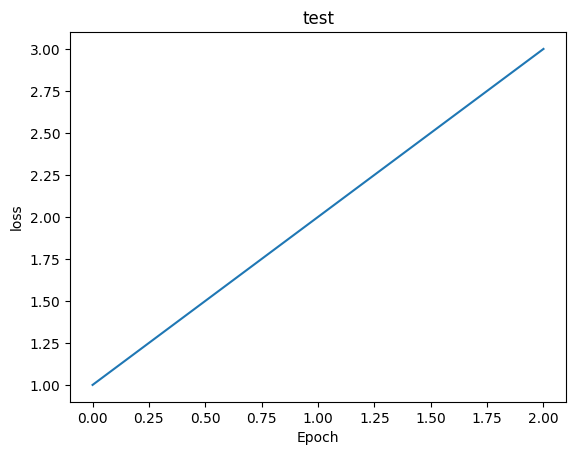

In [47]:
import matplotlib.pyplot as plt
def plot_stat(stat: list, title: str, y_label: str) -> None:
    plt.plot(stat)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(y_label)
    plt.savefig(f"./plots/{title}.jpg")
    plt.show()
    
stat = [1, 2, 3]
plot_stat(stat, "test", "loss")